<a href="https://colab.research.google.com/github/Toquno-sayrin/smart-factory-predictive-maintenance/blob/main/%EB%B0%80%EB%A7%81%EB%A8%B8%EC%8B%A0_%EB%8D%B0%EC%9D%B4%ED%84%B0%EB%B6%84%EC%84%9D.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE

import warnings
warnings.filterwarnings('ignore')

# 시각화 폰트 및 스타일 설정
plt.rc('font', family='Malgun Gothic') # Mac 사용자는 'AppleGothic'으로 변경
plt.rcParams['axes.unicode_minus'] = False
sns.set_style('whitegrid')

In [17]:
df = pd.read_csv('/ai4i2020.csv')

# 컬럼명 직관적으로 변경
df = df.rename(columns={
    'Air temperature [K]': 'Air_temperature',
    'Process temperature [K]': 'Process_temperature',
    'Rotational speed [rpm]': 'Rotational_speed',
    'Torque [Nm]': 'Torque',
    'Tool wear [min]': 'Tool_wear'
})

print(f"데이터 크기: {df.shape}")
display(df.head())

데이터 크기: (10000, 14)


,UDI,Product ID,Type,Air_temperature,Process_temperature,Rotational_speed,Torque,Tool_wear,Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


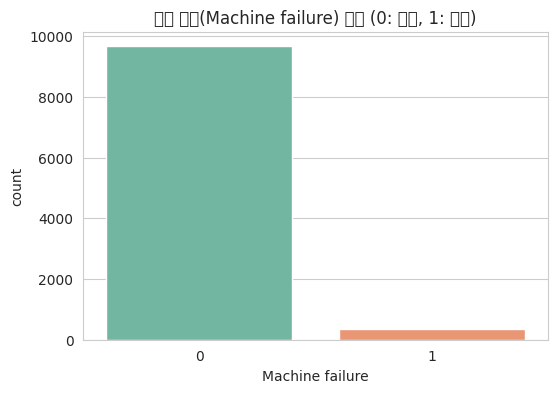

정상 데이터 비율: 96.61%
고장 데이터 비율: 3.39%
=> 💡 심각한 클래스 불균형 확인. 일반적인 학습 시 고장을 제대로 탐지하지 못할 위험이 큼.


In [18]:
# 타깃 변수(Machine failure) 클래스 불균형 확인
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='Machine failure', palette='Set2')
plt.title('고장 여부(Machine failure) 분포 (0: 정상, 1: 고장)')
plt.show()

failure_ratio = df['Machine failure'].value_counts(normalize=True) * 100
print(f"정상 데이터 비율: {failure_ratio[0]:.2f}%")
print(f"고장 데이터 비율: {failure_ratio[1]:.2f}%")
print("=> 💡 심각한 클래스 불균형 확인. 일반적인 학습 시 고장을 제대로 탐지하지 못할 위험이 큼.")

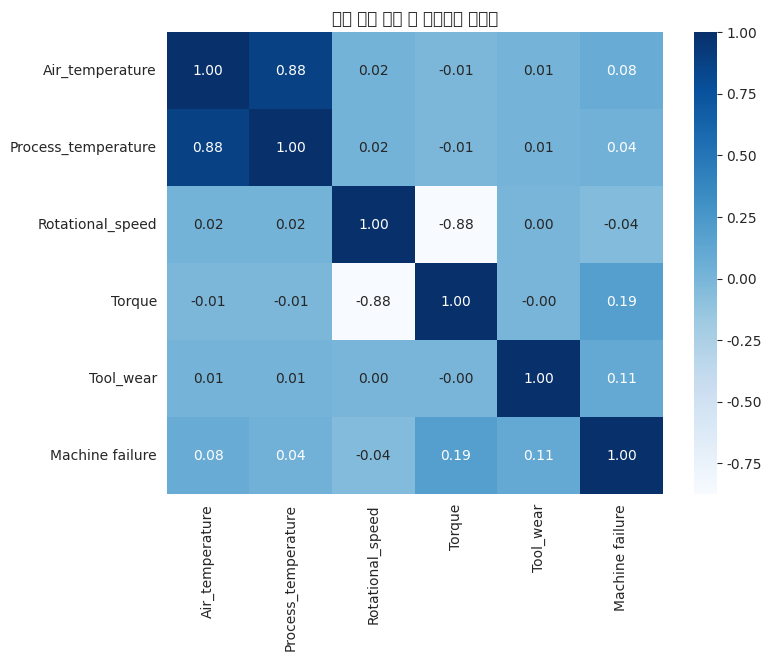

In [19]:
# 수치형 변수들 간의 상관관계 히트맵
numeric_cols = ['Air_temperature', 'Process_temperature', 'Rotational_speed', 'Torque', 'Tool_wear', 'Machine failure']

plt.figure(figsize=(8, 6))
sns.heatmap(df[numeric_cols].corr(), annot=True, fmt='.2f', cmap='Blues')
plt.title('주요 센서 변수 간 상관관계 히트맵')
plt.show()

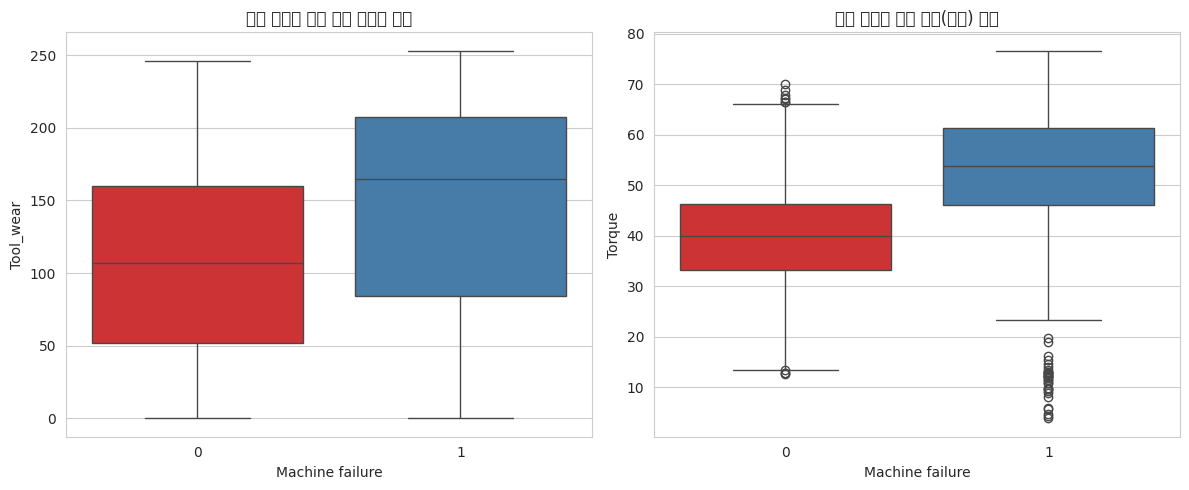

In [20]:
# 고장 여부에 따른 공구 마모도(Tool wear)와 토크(Torque) 분포 차이 확인
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(x='Machine failure', y='Tool_wear', data=df, ax=axes[0], palette='Set1')
axes[0].set_title('고장 여부에 따른 공구 마모도 차이')

sns.boxplot(x='Machine failure', y='Torque', data=df, ax=axes[1], palette='Set1')
axes[1].set_title('고장 여부에 따른 토크(부하) 차이')

plt.tight_layout()
plt.show()

In [21]:
# 불필요한 식별자 및 세부 고장 원인 컬럼 제거
X = df.drop(columns=['UDI', 'Product ID', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF'])
y = df['Machine failure']

# 범주형 변수(Type) 원-핫 인코딩
X = pd.get_dummies(X, columns=['Type'], drop_first=True)

# 데이터 분할 (학습/테스트 8:2) - 층화 추출(stratify) 적용하여 비율 유지
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 수치형 데이터 스케일링 (StandardScaler)
num_features = ['Air_temperature', 'Process_temperature', 'Rotational_speed', 'Torque', 'Tool_wear']
scaler = StandardScaler()

X_train[num_features] = scaler.fit_transform(X_train[num_features])
X_test[num_features] = scaler.transform(X_test[num_features])

print("전처리 완료 후 학습 데이터 형태:", X_train.shape)

전처리 완료 후 학습 데이터 형태: (8000, 7)


=== 모델 평가 결과 ===
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      1932
           1       0.91      0.72      0.80        68

    accuracy                           0.99      2000
   macro avg       0.95      0.86      0.90      2000
weighted avg       0.99      0.99      0.99      2000



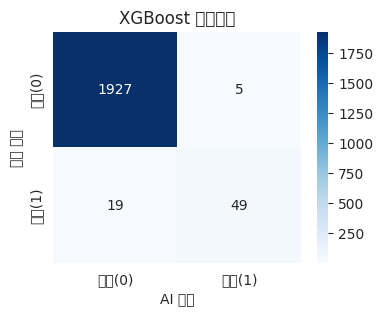

In [24]:
# 데이터 전처리
df_work = df.rename(columns={
    'Air temperature [K]': 'Air_temperature',
    'Process temperature [K]': 'Process_temperature',
    'Rotational speed [rpm]': 'Rotational_speed',
    'Torque [Nm]': 'Torque',
    'Tool wear [min]': 'Tool_wear'
})

df_clean = df_work.drop(columns=['UDI', 'Product ID'])
df_clean = pd.get_dummies(df_clean, columns=['Type'])

target = 'Machine failure'
X = df_clean.drop(columns=[target, 'TWF', 'HDF', 'PWF', 'OSF', 'RNF'])
y = df_clean[target]

numeric_cols = ['Air_temperature', 'Process_temperature', 'Rotational_speed', 'Torque', 'Tool_wear']
scaler = StandardScaler()
X[numeric_cols] = scaler.fit_transform(X[numeric_cols])

# random_state 및 stratify 적용
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

model = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("=== 모델 평가 결과 ===")
print(classification_report(y_test, y_pred))

# 혼동 행렬 시각화
plt.figure(figsize=(4, 3))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues',
            xticklabels=['정상(0)', '고장(1)'], yticklabels=['정상(0)', '고장(1)'])
plt.title('XGBoost 혼동행렬')
plt.ylabel('실제 정답')
plt.xlabel('AI 예측')
plt.show()